STAGE 2: DATA CLEANING

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("dataset.csv")

# First 5 rows
df.head()
# Last 5 rows
df.tail()
# Shape
df.shape
# Column names
df.columns
# Data types
df.dtypes
# General information
df.info()
'''
df describe give min/max/mean for every numerical column  
'''
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


3. Missing values
df.isnull().sum()
This gives you a count per column. Ask yourself: if a column has missing values, how many, and does it matter? A handful of missing track_name might be droppable; thousands missing in danceability would be a bigger problem.

In [3]:
df.isnull().sum()
df[df["artists"].isnull()] #this will show you the row who has artist null
df=df.dropna(subset=["artists"]) #drop the row which has no value for artists

In [4]:
''' 
when all columns were printed there was a column named 'unnamed' which basically was
classic pandas artifact-pandas default index included as extra column
'''
df['Unnamed: 0'].head()
df = df.drop(columns=['Unnamed: 0'])


In [5]:
df.duplicated().sum() # fully identical rows outputs 450 we should remove these duplicates
df=df.drop_duplicates()
df.duplicated(subset=['track_name','artists']).sum()   #same song, different row (common in this dataset — same track appears in multiple genres) outputs 32206
df[df.duplicated(subset=['track_name','artists'], keep=False)].sort_values('track_name').head(10)
''' 
there are some songs which are listed twice because of the genre they have more than 1 genre so i keep all these songs and decide to treat "song+genre" 
as actual unit of analysis not just song
'''

' \nthere are some songs which are listed twice because of the genre they have more than 1 genre so i keep all these songs and decide to treat "song+genre" \nas actual unit of analysis not just song\n'

In [6]:
''' 
Each should return an empty dataframe if the data's 
 clean. If not, you've found something to fix or drop.
'''
df[df["danceability"]>1]
df[df["energy"]>1]
df[df["popularity"]>100]
df[df['tempo'] <= 0].shape[0]
#since there are only 157 rows who has tempo 0 means they have no rythm
df = df[df['tempo'] > 0]
#  Drop track_id — it's just an ID, not useful for analysis
df = df.drop(columns=['track_id'])


In [7]:
# Final check after cleaning data
print(df.shape)
df.isnull().sum()

(113392, 19)


artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

STAGE 2:  Exploratory Data Analysis (EDA)
Goal: Discover interesting patterns.

-> General:
What is the average popularity?
What is the median popularity?
Which song is the most popular?
Which song is the least popular?
What is the popularity distribution?

33.31907012840412 35.0
count    113392.00000
mean         33.31907
std          22.29502
min           0.00000
25%          17.00000
50%          35.00000
75%          50.00000
max         100.00000
Name: popularity, dtype: float64


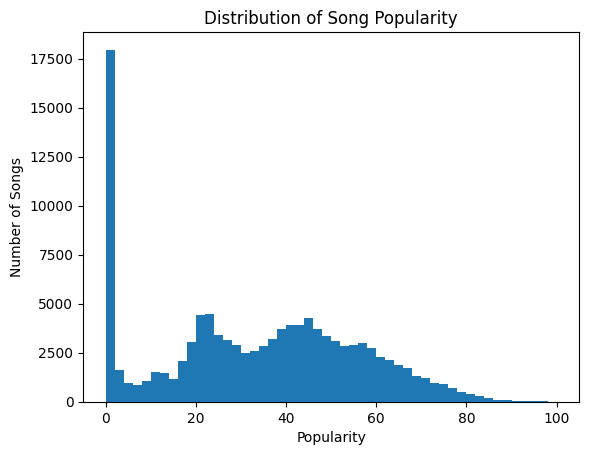

In [8]:
#average popularity
average_popularity=df["popularity"].mean()
#median popularity
median_popularity=df["popularity"].median()
print(average_popularity,median_popularity)
#there are 2 methods for finding most popular song
#option:1
''' 
ascending=True → Lowest marks first.
ascending=False → Highest marks first.
.head(1) means: Give me the first 1 row.
'''
df.sort_values("popularity",ascending=False).head(1)
#option#2
df.loc[df['popularity'].idxmax()]
#least popular song:
df.loc[df["popularity"].idxmin()]
#popularity distribution:
print(df["popularity"].describe()) #summary stastics
plt.hist(df['popularity'],bins=50)
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.show()

-> Genre Analysis
Which genre has the highest average popularity?
Which genre has the lowest?
Which genre has the highest average energy?
Which genre is the happiest (highest valence)?
Which genre is the most danceable?

In [9]:
#high avg popularity acc to genre
grp=df.groupby("track_genre")
grp['popularity'].mean().sort_values(ascending=False).head(1)
#df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(1)
#low avg popularity acc to genre
grp['popularity'].mean().sort_values(ascending=True).head(1)
#high avg energy
grp['energy'].mean().sort_values(ascending=False).head(1)
#happiest genre
grp['valence'].mean().sort_values(ascending=False).head(1)
#most danceable
grp['danceability'].mean().sort_values(ascending=False).head(1)



track_genre
kids    0.77863
Name: danceability, dtype: float64

-> Feature Relationships
Does energy correlate with popularity?
Does danceability correlate with popularity?
Does loudness correlate with popularity?
Does acousticness affect popularity?
Does tempo affect popularity?

What is Correlation?
Correlation tells us:
How strongly two variables are related to each other.
**positive correlation:**
For example, suppose we have students.
| Student | Hours Studied | Marks |
| ------- | ------------: | ----: |
| A       |             1 |    45 |
| B       |             2 |    55 |
| C       |             3 |    65 |
| D       |             4 |    75 |
| E       |             5 |    90 |
Notice:
As hours studied increase, marks also increase.
These two variables are positively correlated.
Marks
100 |                 •
 90 |             •
 80 |          •
 70 |       •
 60 |    •
 50 | •
    +------------------------
      1  2  3  4  5
      Hours Studied
**negative correlation:**
| Hours Playing Games | Exam Marks |
| ------------------: | ---------: |
|                   1 |         95 |
|                   2 |         88 |
|                   3 |         80 |
|                   4 |         72 |
|                   5 |         60 |
As gaming hours increase,
Marks decrease.
This is negative correlation.
Marks
100 | •
 90 |    •
 80 |       •
 70 |          •
 60 |             •
 50 |                •
    +------------------------
      1  2  3  4  5
      Hours Gaming
**no correlation:**
Suppose
| Shoe Size |  IQ |
| --------: | --: |
|         6 | 100 |
|         7 | 110 |
|         8 |  90 |
|         9 | 105 |

There is no meaningful relationship.
Knowing someone's shoe size doesn't help predict their IQ.
This is no correlation.
Marks
100 |      •
 90 |  •
 80 |          •
 70 |      •
 60 | •
 50 |            •
    +------------------------

**Correlation Coefficient**
The correlation coefficient is just a number that tells us:
How strong the relationship is.
Whether it's positive or negative.
It is usually represented by r.
The value of r is always between:
-1  ------------------  0  ------------------  +1
1. r = +1 : Perfect positive correlation.
when Hours Studied ↑ Marks ↑
Every increase in study hours leads to a proportional increase in marks.
2. r = -1 : Perfect negative correlation.
Gaming ↑ Marks ↓
3. r = 0: No relationship.
No clear pattern.
**strength of correlation**
| Correlation Coefficient | Meaning              |
| ----------------------: | -------------------- |
|                    +1.0 | Perfect positive     |
|                    +0.8 | Very strong positive |
|                    +0.5 | Moderate positive    |
|                    +0.2 | Weak positive        |
|                       0 | No correlation       |
|                    -0.2 | Weak negative        |
|                    -0.5 | Moderate negative    |
|                    -0.8 | Very strong negative |
|                    -1.0 | Perfect negative     |


In [10]:
#correlation coefficient
print(df['popularity'].corr(df['energy']))
print(df['popularity'].corr(df['danceability']))
print(df['popularity'].corr(df['loudness']))
print(df['popularity'].corr(df['acousticness']))
print(df['popularity'].corr(df['tempo']))

-0.0019731100473836774
0.035464029347419955
0.048442588734442425
-0.022464260848315636
0.01332444028336874


<Axes: xlabel='energy', ylabel='popularity'>

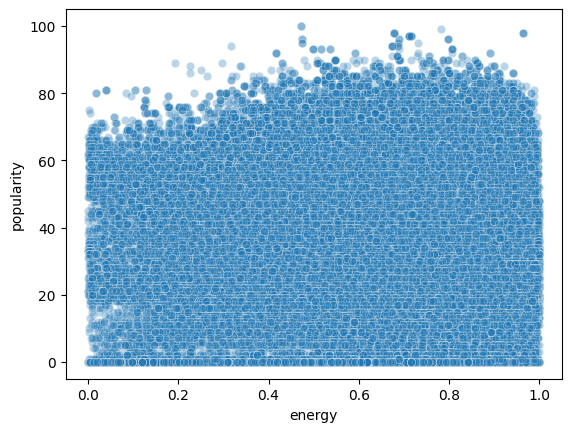

In [11]:
#visual way- scatterplot
#energy and popularity
sns.scatterplot(x='energy',y='popularity',data=df,alpha=0.3)


<Axes: xlabel='danceability', ylabel='popularity'>

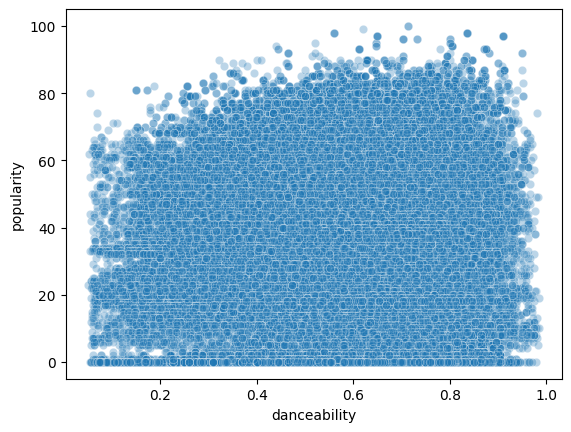

In [12]:
#danceability and popularity
sns.scatterplot(x='danceability',y='popularity',data=df,alpha=0.3)

<Axes: xlabel='loudness', ylabel='popularity'>

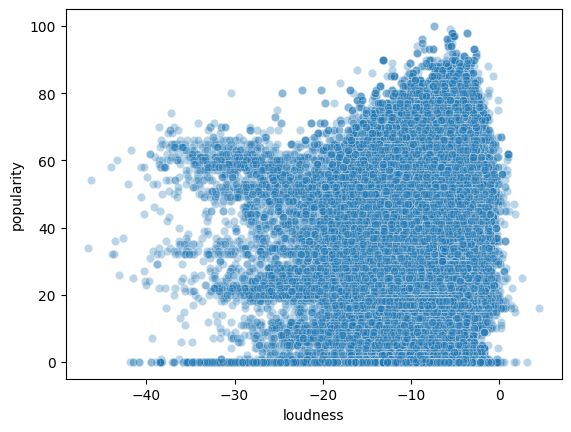

In [13]:
#loudness and popularity
sns.scatterplot(x='loudness',y='popularity',data=df,alpha=0.3)


<Axes: xlabel='acousticness', ylabel='popularity'>

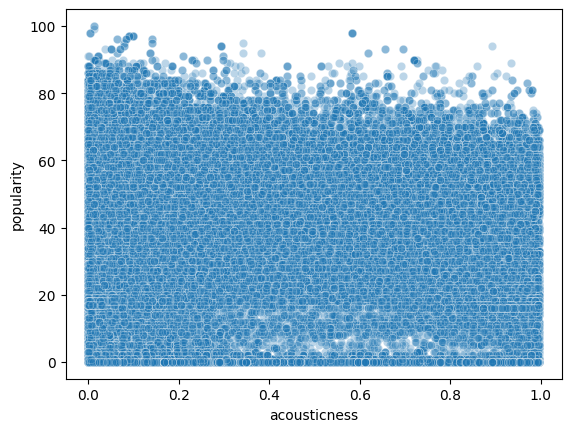

In [14]:
#acousticness and popularity
sns.scatterplot(x='acousticness',y='popularity',data=df,alpha=0.3)

<Axes: xlabel='tempo', ylabel='popularity'>

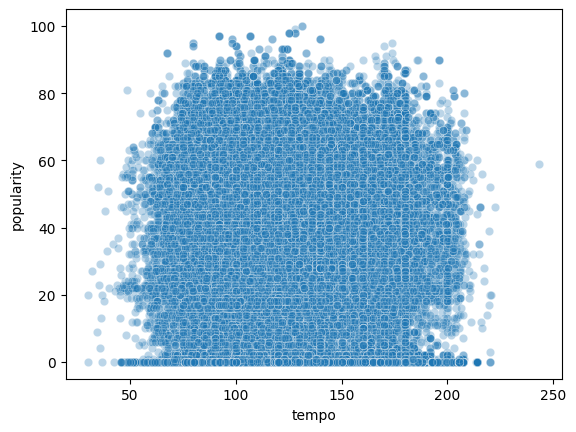

In [15]:
#tempo and popularity
sns.scatterplot(x='tempo',y='popularity',data=df,alpha=0.3)

**Artists**
Which artists appear most frequently?
Which artist has the highest average popularity?

In [16]:
#frequently appearing
df['artists'].value_counts().head(10)

artists
The Beatles        279
George Jones       260
Stevie Wonder      235
Linkin Park        224
Ella Fitzgerald    221
Prateek Kuhad      217
Feid               201
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

In [17]:
#high avg popularity
fap=df.groupby('artists')
fap['popularity'].mean().sort_values(ascending=False).head(10)

artists
Sam Smith;Kim Petras           100.0
Bizarrap;Quevedo                99.0
Manuel Turizo                   98.0
Bad Bunny;Chencho Corleone      97.0
Bad Bunny;Bomba Estéreo         94.5
Joji                            94.0
Beyoncé                         93.0
Harry Styles                    92.0
Rema;Selena Gomez               92.0
Rauw Alejandro;Lyanno;Brray     91.0
Name: popularity, dtype: float64

**Explicit Songs**
Are explicit songs generally more popular?

explicit
False    33.018577
True     36.524799
Name: popularity, dtype: float64
explicit
False    103674
True       9718
Name: count, dtype: int64
explicit
False    34.0
True     37.5
Name: popularity, dtype: float64


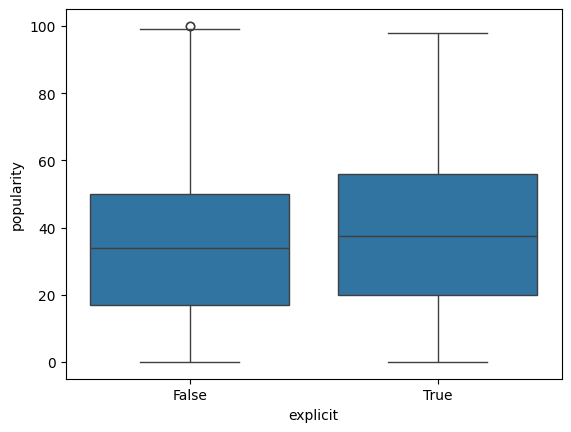

In [18]:
es=df.groupby('explicit')
print(es['popularity'].mean())
print(df['explicit'].value_counts())
sns.boxplot(x='explicit', y='popularity', data=df)
print(es['popularity'].median())

In [19]:
#High energy but low popularity:
df[(df['energy'] > 0.8) & (df['popularity'] < 20)][['track_name','artists','energy','popularity']].head(10)
#Very acoustic but still popular (the reverse case from your plan):
df[(df['acousticness'] > 0.8) & (df['popularity'] > 70)][['track_name','artists','acousticness','popularity']].head(10)
# High danceability but unpopular
df[(df['danceability'] > 0.8) & (df['popularity'] < 20)][['track_name','artists','danceability','popularity']].head(10)

# Very loud but unpopular
df[(df['loudness'] > -3) & (df['popularity'] < 20)][['track_name','artists','loudness','popularity']].head(10)

# High valence (happy-sounding) but very unpopular
df[(df['valence'] > 0.8) & (df['popularity'] < 10)][['track_name','artists','valence','popularity']].head(10)

,track_name,artists,valence,popularity
98,Hold On,KT Tunstall,0.805,0
197,Stumble,Freddie King,0.857,0
198,Paradise,Taj Mahal,0.862,0
1088,Nontsokolo,Hugh Masekela,0.942,0
1089,Soul Makossa,Manu Dibango,0.921,0
1092,District Six - Live,Hugh Masekela,0.858,0
1094,Women Of The Sun,Hugh Masekela,0.959,0
1098,District Six - Live,Hugh Masekela,0.858,0
1137,District Six - Live,Hugh Masekela,0.858,0
1146,District Six - Live,Hugh Masekela,0.858,0


**Create these plots**
Popularity histogram ✅
Popularity boxplot✅
Genre frequency bar chart✅
Top 10 genres by average popularity ✅
Top 10 artists by number of songs✅
Energy distribution ✅
Danceability distribution ✅
Tempo distribution✅
Scatter plot: Energy vs Popularity ✅
Scatter plot: Danceability vs Popularity✅
Scatter plot: Valence vs Popularity✅
Correlation heatmap
Pairplot of important numerical features
Boxplot of popularity by genre✅
Countplot of explicit vs non-explicit songs

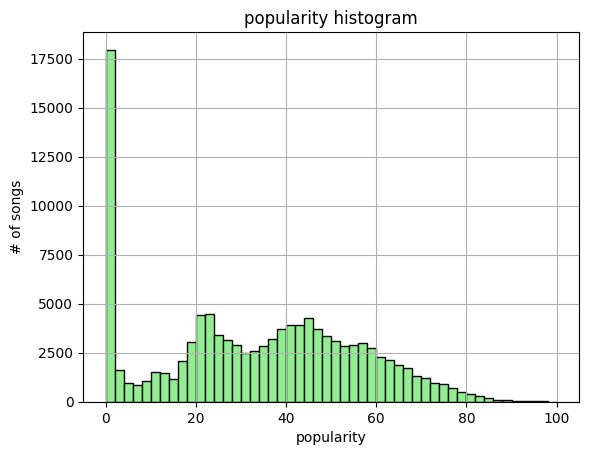

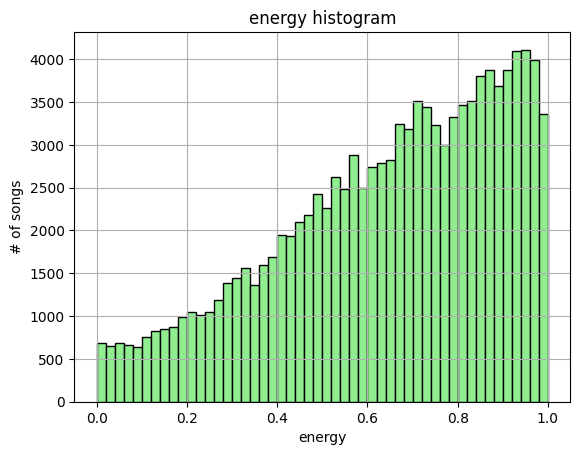

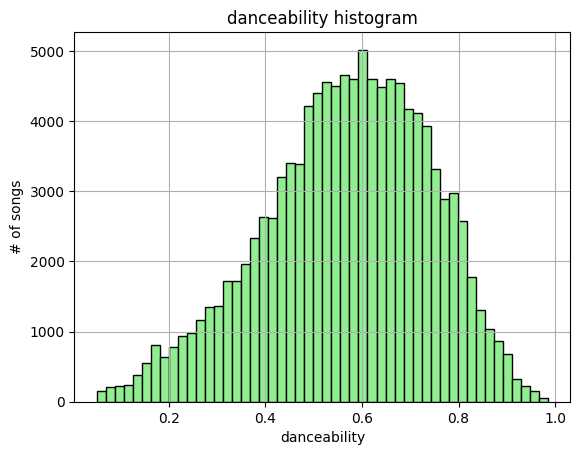

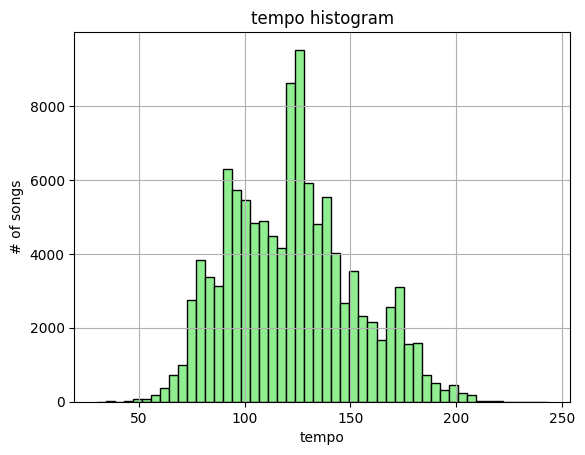

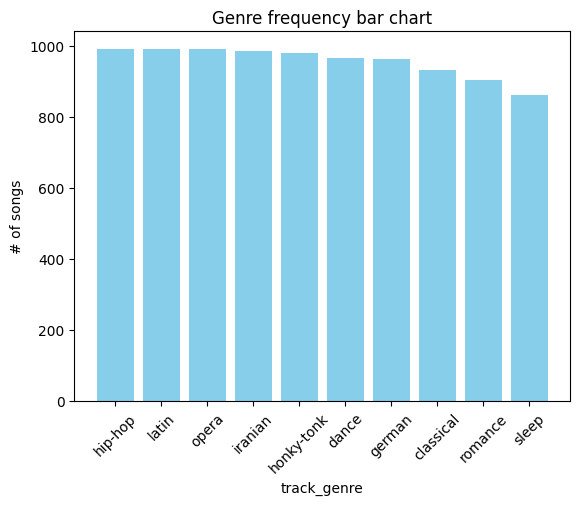

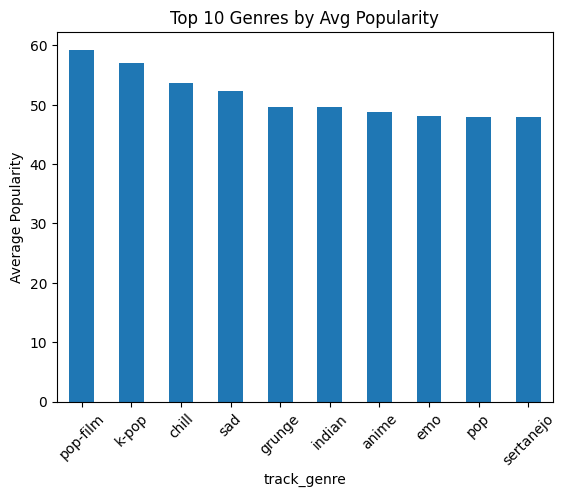

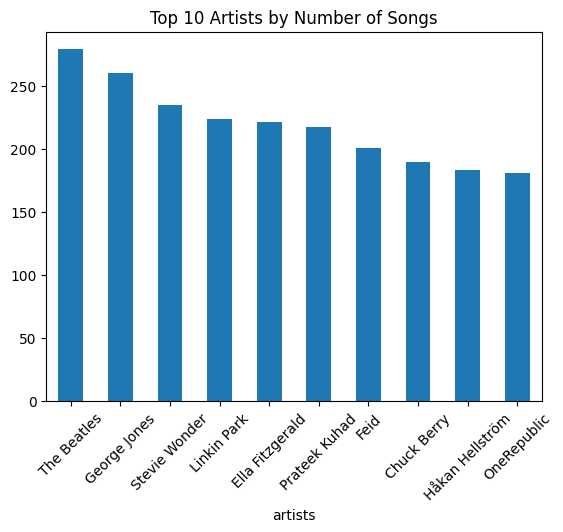

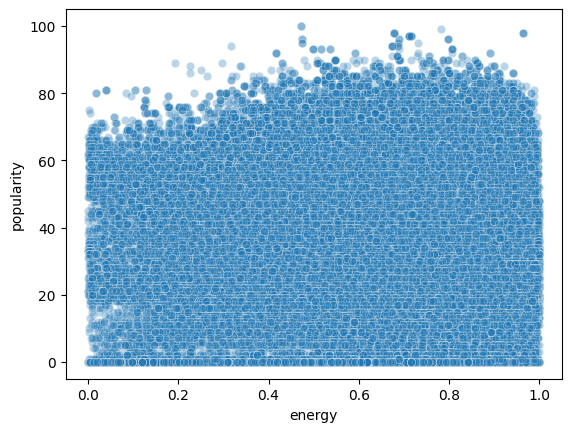

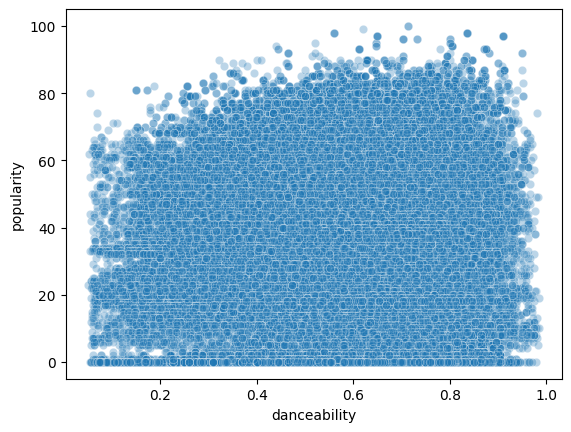

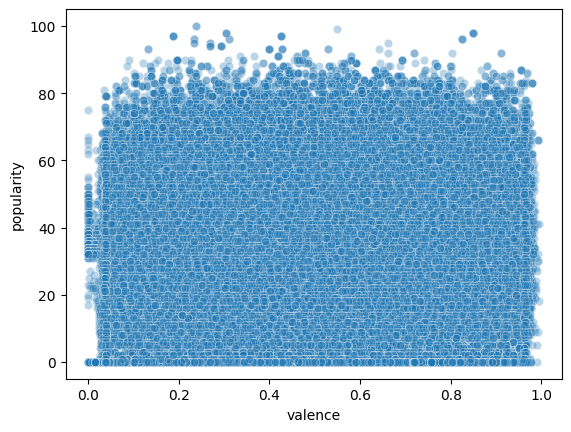

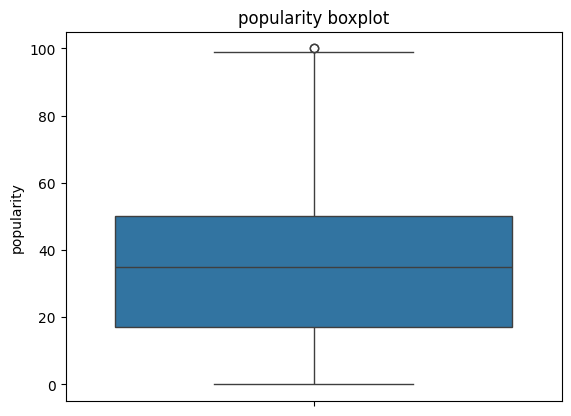

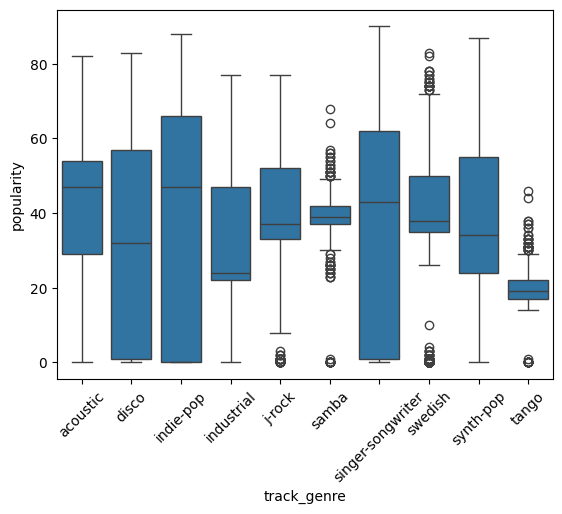

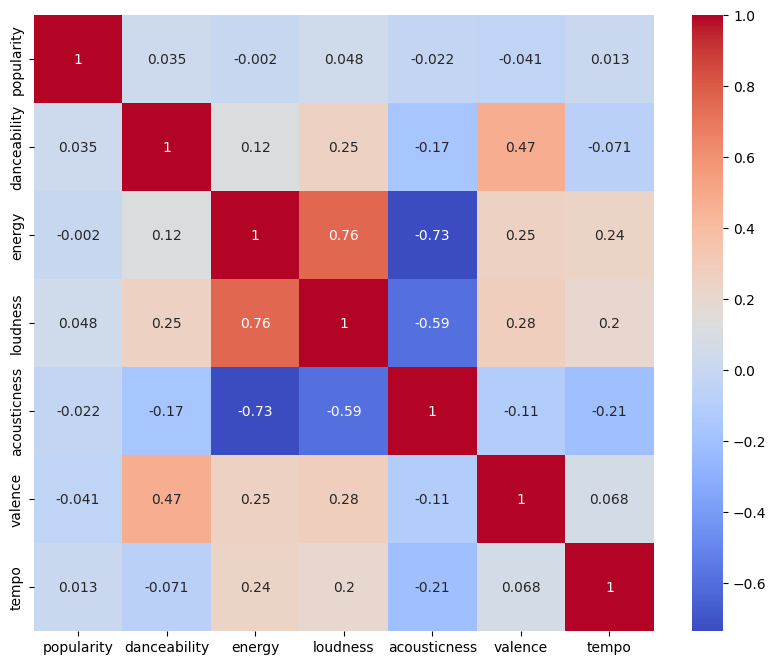

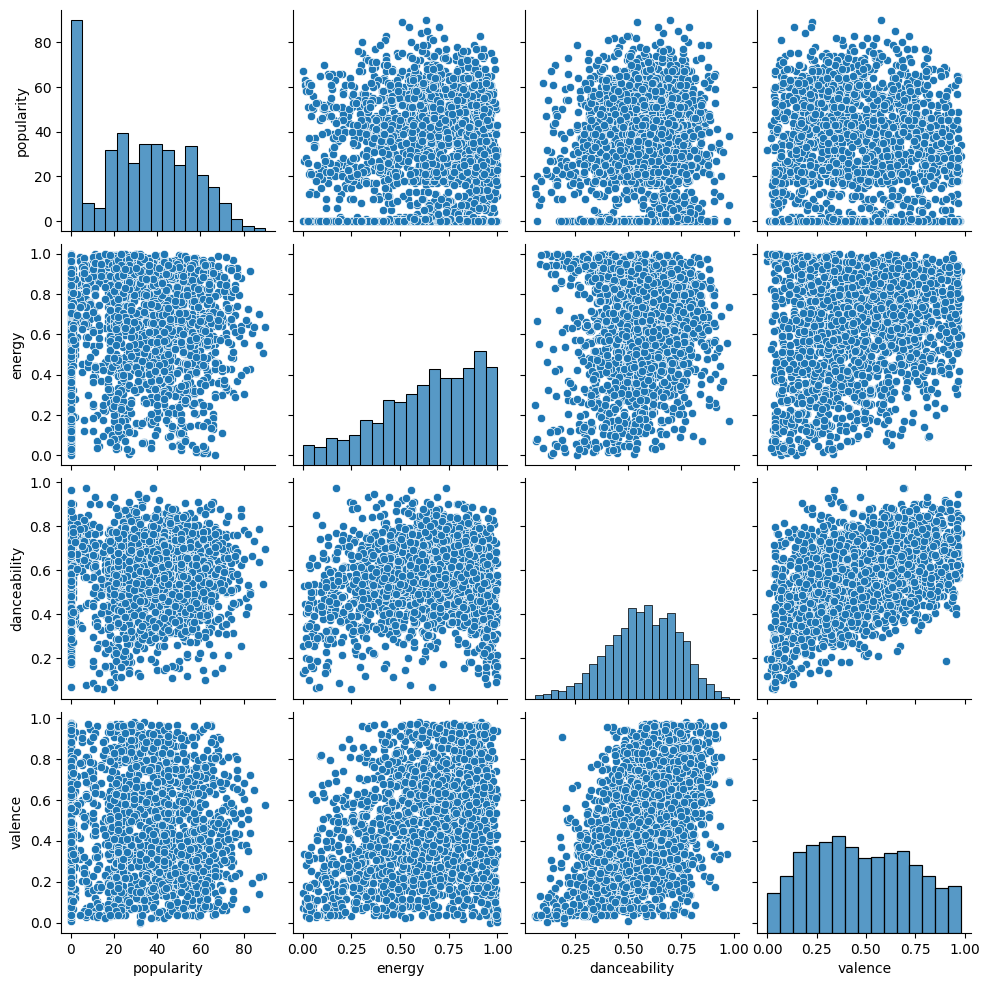

In [20]:
'''
value_counts() is essentially a shortcut that does "group
 by this column, count rows in each group, sort descending" 
'''
#Popularity histogram
plt.hist(df['popularity'],bins=50,color='lightgreen',edgecolor='black')
plt.title("popularity histogram")
plt.xlabel("popularity")
plt.ylabel("# of songs")
plt.grid(True)
plt.show()
#energy dist
plt.hist(df['energy'],bins=50,color='lightgreen',edgecolor='black')
plt.title("energy histogram")
plt.xlabel("energy")
plt.ylabel("# of songs")
plt.grid(True)
plt.show()
#danceability distribution 
plt.hist(df['danceability'],bins=50,color='lightgreen',edgecolor='black')
plt.title("danceability histogram")
plt.xlabel("danceability")
plt.ylabel("# of songs")
plt.grid(True)
plt.show()
#tempo distribution
plt.hist(df['tempo'],bins=50,color='lightgreen',edgecolor='black')
plt.title("tempo histogram")
plt.xlabel("tempo")
plt.ylabel("# of songs")
plt.grid(True)
plt.show()
#Genre frequency bar chart
genre_counts = df['track_genre'].value_counts().tail(10)
plt.bar(genre_counts.index, genre_counts.values, color='skyblue')
plt.title("Genre frequency bar chart")
plt.xlabel("track_genre")
plt.ylabel("# of songs")
plt.xticks(rotation=45)
plt.show()

#Top 10 genres by average popularity 
df.groupby("track_genre")['popularity'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Genres by Avg Popularity')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45)
plt.show()

#Top 10 artists by number of songs
df['artists'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Artists by Number of Songs')
plt.xticks(rotation=45)
plt.show()
#Scatter plot: Energy vs Popularity 
sns.scatterplot(x='energy',y='popularity',data=df,alpha=0.3)
plt.show()
#Scatter plot: Danceability vs Popularity
sns.scatterplot(x='danceability',y='popularity',data=df,alpha=0.3)
plt.show()
#Scatter plot: Valence vs Popularity
sns.scatterplot(x='valence',y='popularity',data=df,alpha=0.3)
plt.show()
#Popularity boxplot
sns.boxplot(y=df['popularity'])
plt.title('popularity boxplot')
plt.show()
# Boxplot of popularity BY genre - only makes sense for top genres, or it's unreadable
top_genres = df['track_genre'].value_counts().head(10).index
sns.boxplot(x='track_genre', y='popularity', data=df[df['track_genre'].isin(top_genres)])
plt.xticks(rotation=45)
plt.show()
#correlation heatmap
corr = df[['popularity','danceability','energy','loudness','acousticness','valence','tempo']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
#pairplot
sample = df.sample(2000)  # IMPORTANT: pairplot on 114k rows will take forever/crash — sample first
sns.pairplot(sample[['popularity','energy','danceability','valence']])
plt.show()



**⚙️ Phase 5: Feature Engineering (Mission 5)**

Goal: Create better features.

**Tasks**
Convert duration from milliseconds to minutes.
Create a "High Energy" feature.
Create a "Fast Tempo" feature.
Create a "Mood Score" using valence and energy.
Normalize numerical features (later for ML).
Encode categorical columns if needed.
Decide which features should be used for prediction.

In [21]:
#duration in minutes
df['duration_min']=df['duration_ms']/60000
#high energy flag
df['high_energy'] = df['energy'] > 0.8
#fast tempo feature
avg_tempo = df['tempo'].mean()
df['fast_tempo'] = df['tempo'] > avg_tempo
#mood score
df['mood_score'] = (df['valence'] + df['energy']) / 2

the next part is making the data suitable for ML model to use the problem with current data is that ML models require all the data in numeric form and normalized form

One-Hot Encoding:

**What is get_dummies()?**
Computers cannot understand words like "pop" or "rock" directly. They understand numbers.So get_dummies() converts each category into separate columns containing only 0s and 1s.
Instead of:
| track_genre |
| ----------- |
| pop         |
| rock        |
| jazz        |
| pop         |
it becomes
| genre_jazz | genre_pop | genre_rock |
| ---------- | --------- | ---------- |
| 0          | 1         | 0          |
| 0          | 0         | 1          |
| 1          | 0         | 0          |
| 0          | 1         | 0          |
**What is concat()?**
concat() means join things together.
Here it joins:
your original dataframe (df)
the new dummy columns (genre_encoded)

**What does axis=1 mean?**
axis=1 means ➡️ Add columns Imagine sticking new columns to the right side of the table.
If it were axis=0 it would add rows instead.


**Why do we do this?**
Machine learning algorithms generally cannot use text values like:
pop
rock
jazz
But they can use
genre_pop   genre_rock   genre_jazz
1           0            0
0           1            0
0           0            1
This process is called One-Hot Encoding.

**one hot encoder:**
it turns multiple values for a column into multiple columns that can be 0 or 1 (like a boolean value)

**workflow while using any encoder:**
1.create encoder
2.fit_transform on the column
3.get proper column names 
4.build a new dataframe 
5.concat back with the original data minus the raw text column. 
**answers to some questions:**
1. Why fit_transform after creating the encoder?
Creating encoder = OneHotEncoder(...) just builds an empty tool — it doesn't know anything about your actual data yet. It has no idea what genres exist in your track_genre column.
fit_transform() does two jobs in one call:

fit — looks at your data and learns what it needs to know (in this case: "what are all the unique categories in this column?" — pop, rock, k-pop, etc.)
transform — actually converts your data using what it just learned (turns each genre into a row of 0s and a single 1)
2. Does pd.DataFrame(...) convert the encoded values into a dataframe?
Yes, exactly. Here's why that step is even needed: encoder.fit_transform() doesn't return a pandas DataFrame — it returns a plain numpy array (just rows and columns of numbers, no column names, no index). That's fine for feeding into a model directly, but not great for you to read, inspect, or concat() back with your original dataframe.
python
df_encoded = pd.DataFrame(encoded_values, columns=new_cols, index=df.index)
This line takes that raw numpy array and wraps it into a proper DataFrame — giving it real column names (new_cols, like track_genre_pop, track_genre_rock) and matching row index (index=df.index) so it lines up correctly with your original df when you combine them later.
That index=df.index part matters a lot — without it, df_encoded would get a fresh default index (0, 1, 2, 3...), which might not match up correctly with df's actual row index if df has ever been filtered, sorted, or had rows dropped earlier (yours has, remember the duplicate/null drops in Stage 1). Mismatched indexes during concat() can silently create wrong pairings or extra NaN rows.

4. What does encoder.get_feature_names_out() do?
After one-hot encoding, you get a bunch of new columns, but numpy doesn't automatically know what to call them — it's just an array of 0s and 1s with no labels. get_feature_names_out() generates sensible, readable column names for you, based on the original column name + each unique category found.



In [26]:
from sklearn.preprocessing import OneHotEncoder

In [28]:
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoded_values=encoder.fit_transform(df[['track_genre']])
new_cols=encoder.get_feature_names_out(['track_genre'])

In [29]:
df_encoded=pd.DataFrame(encoded_values,columns=new_cols,index=df.index)
data_final=pd.concat(
    [df.drop(columns=['track_genre']),df_encoded],
    axis=1
)

**Why normalization matters before feeding data to a model**
Here's the actual reasoning, not just "it's a rule":
The problem it solves: your features live on wildly different scales. Look at your own data — energy ranges 0 to 1, but loudness ranges roughly -46 to +4, and duration_min ranges from under 1 to nearly 90. If you feed these raw numbers into certain models, the model has no inherent way of knowing that a difference of "50" in loudness isn't inherently more important than a difference of "0.5" in `energy" — it just sees bigger numbers and can end up weighting them unevenly, purely because of the units you happened to measure in, not because they're actually more predictive.

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
cols_to_scale = ['duration_min', 'loudness', 'tempo']
data_final[cols_to_scale]=scaler.fit_transform(data_final[cols_to_scale])
data_final[cols_to_scale].describe()


,duration_min,loudness,tempo
count,113392.000000,113392.000000,113392.000000
mean,0.040670,0.750480,0.432256
std,0.020188,0.097322,0.139074
min,0.000000,0.000000,0.000000
25%,0.030362,0.716116,0.325118
50%,0.037780,0.774622,0.430770
75%,0.047084,0.813587,0.515457
max,1.000000,1.000000,1.000000


**Why fit_transform after creating the scaler**
Same two-step logic as before, applied specifically to your code:
pythonscaler = MinMaxScaler()
This just creates an empty, "un-taught" scaler — at this point it knows nothing about your data. It doesn't know that tempo ranges 30-243, or that loudness ranges -46 to +4. It's just a blank tool.
pythondata_final[cols_to_scale] = scaler.fit_transform(data_final[cols_to_scale])
fit_transform() does two things in a single call:

fit — looks at data_final[cols_to_scale] and learns the actual min and max of each of those three columns (this is the "learning" step — the scaler now knows, for example, that tempo's min is 30.2 and max is 243.37)
transform — takes that learned min/max and actually applies the rescaling formula to every value:

scaled_value = (original_value - min) / (max - min)

In [32]:
X = data_final.drop(columns=['popularity', 'track_name', 'artists', 'album_name', 'duration_ms'])
y = data_final['popularity']

In [33]:
from sklearn.model_selection import train_test_split


In [36]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((90713, 131), (22679, 131), (90713,), (22679,))

LINEAR REGRESSION MODEL TRAINING:

In [40]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

In [42]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2=r2_score(y_test,lr_predictions)
mae=mean_absolute_error(y_test,lr_predictions)
rmse=np.sqrt(mean_squared_error(y_test,lr_predictions))
print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.26648498301930257
MAE: 13.994790560693986
RMSE: 19.058188604457815


Decision Tree Regressor:

In [43]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

dt_r2 = r2_score(y_test, dt_predictions)
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))

print("Decision Tree R²:", dt_r2)
print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)

Decision Tree R²: 0.10188793057073409
Decision Tree MAE: 12.809237465860477
Decision Tree RMSE: 21.088339380433773


Random Forest Regressor:

In [47]:
from sklearn.ensemble import RandomForestRegressor

# Give Random Forest a real chance, closer to default settings
rf_model_full = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=20)
rf_model_full.fit(X_train, y_train)
rf_predictions_full = rf_model_full.predict(X_test)

print("R²:", r2_score(y_test, rf_predictions_full))
print("MAE:", mean_absolute_error(y_test, rf_predictions_full))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions_full)))

R²: 0.19795293731115404
MAE: 15.754362332530523
RMSE: 19.928611558807788
